# PSF and Pupil Visualization

This notebook demonstrates visualization of PSF and pupil functions, including the interpretation of different quantities (modulus, phase, intensity, amplitude).

## Import Libraries

In [1]:
import math
from psf_generator.propagators import VectorialSphericalPropagator, VectorialCartesianPropagator
from psf_generator.utils.plots import plot_pupil, plot_psf

## Computing a 3D Vectorial PSF

We compute a high-NA 3D PSF with circular polarization $(e_0^x, e_0^y) = (\frac{\sqrt{2}}{2}, \frac{\sqrt{2}}{2}i)$.

In [2]:
kwargs = {
    'n_pix_pupil': 127,
    'n_pix_psf': 256,
    'na': 1.3,
    'wavelength': 600,
    'pix_size': 10,
    'defocus_step': 25,
    'n_defocus': 300,
    'e0x': math.sqrt(2) / 2,
    'e0y': math.sqrt(2) / 2 * 1j,
}
propagator = VectorialSphericalPropagator(**kwargs)

### PSF Computation

In [3]:
psf = propagator.compute_focus_field()

## Visualization of PSF Quantities

For 3D PSFs, three orthogonal slices (xy, xz, yz) are shown for each quantity:

**Vectorial propagators** output three field components $(\mathbf{e}_x, \mathbf{e}_y, \mathbf{e}_z)$:
- **Modulus**: Shows $|\mathbf{e}_i|$ for each component
- **Phase**: Shows $\arg(\mathbf{e}_i)$ for each component
- **Intensity**: $I = |\mathbf{e}_x|^2 + |\mathbf{e}_y|^2 + |\mathbf{e}_z|^2$
- **Amplitude**: $A = \sqrt{I}$

**Scalar propagators** output a single field component, so $N=1$ in the above expressions.

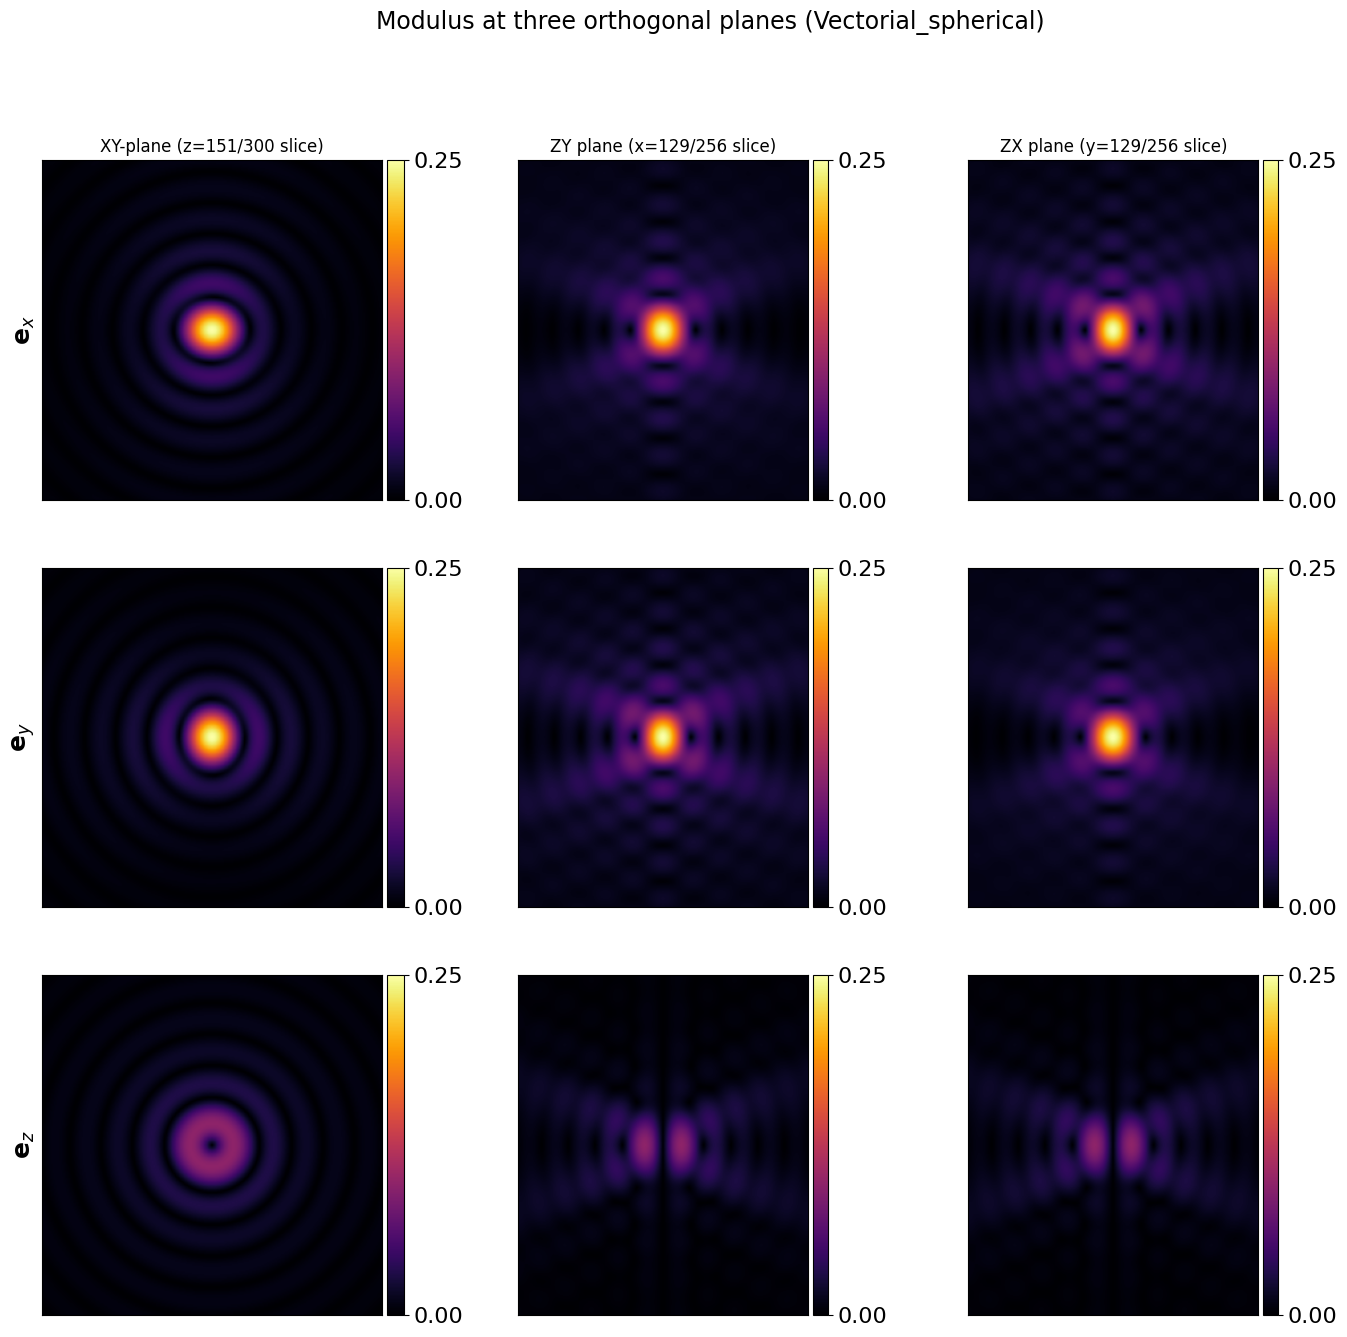

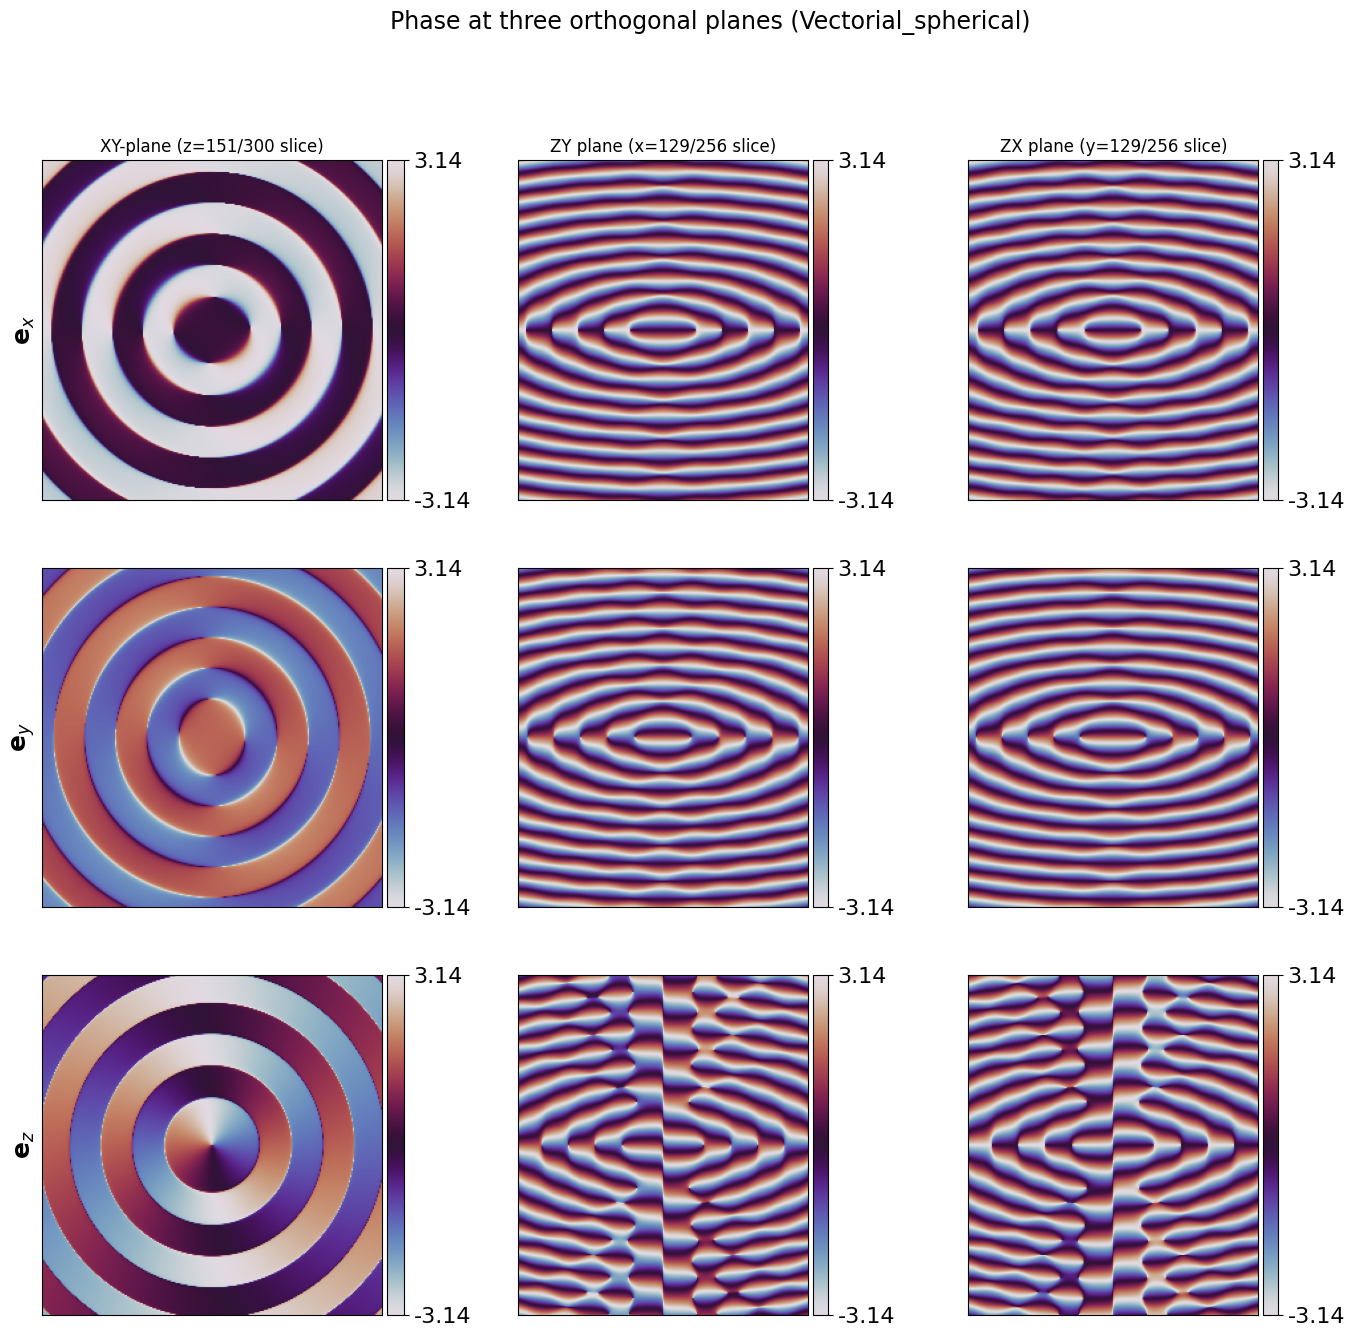

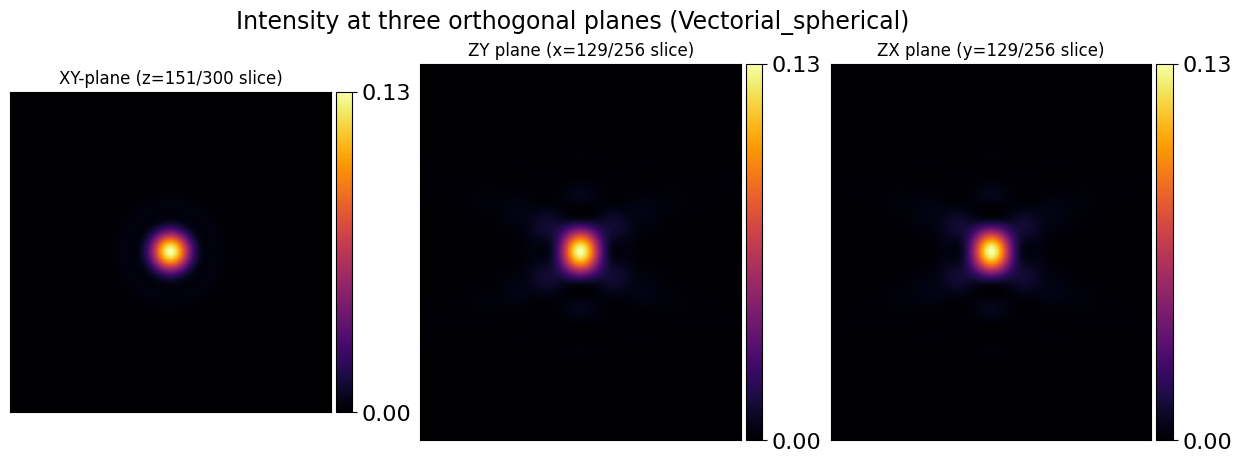

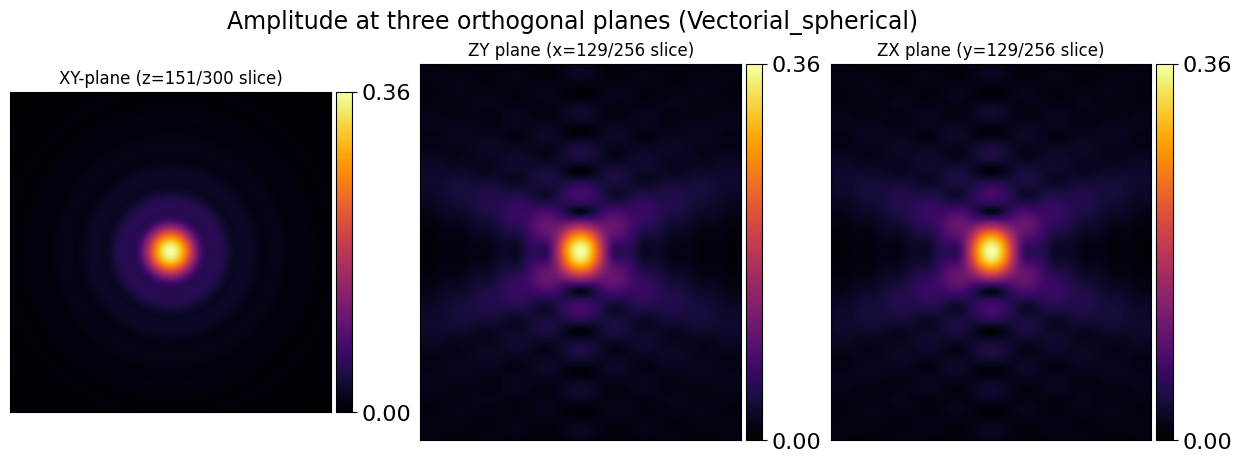

In [4]:
for quantity in ['modulus', 'phase', 'intensity', 'amplitude']:
    plot_psf(
        psf=psf,
        name_of_propagator=propagator.get_name(),
        quantity=quantity,
        show_titles=True,
        show_cbar_ticks=True
    )

## Pupil Function Visualization

The pupil function can be visualized to inspect applied aberrations. The `plot_pupil` function displays both modulus and phase.

**Note**: Spherical propagators represent the pupil as 1D radial profiles (not 2D images). To visualize the pupil, use the corresponding Cartesian propagator.

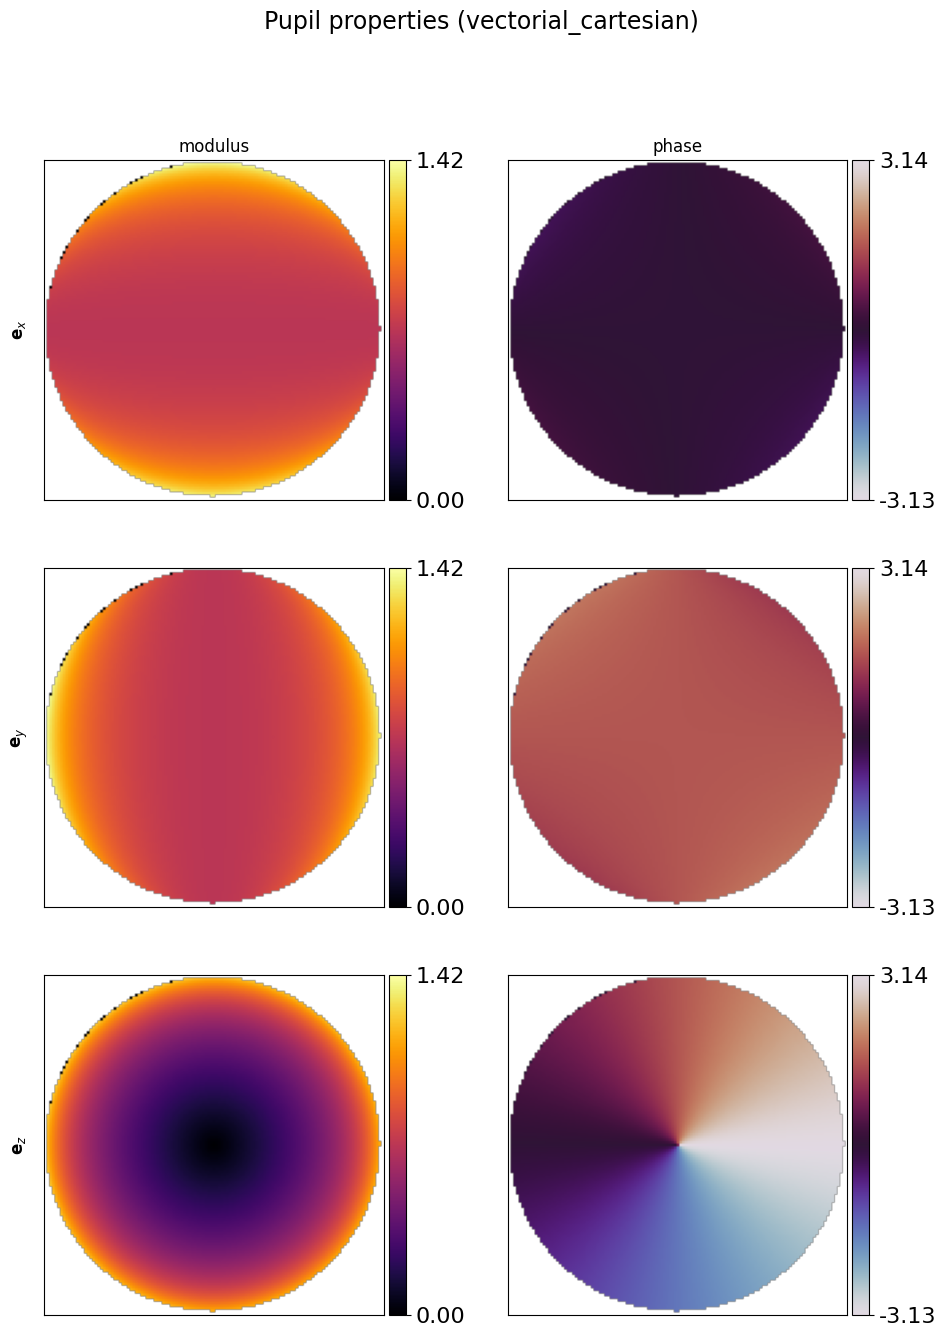

In [5]:
# Use Cartesian propagator for pupil visualization
propagator_cartesian = VectorialCartesianPropagator(**kwargs)
pupil = propagator_cartesian.get_pupil()
plot_pupil(
    pupil=pupil,
    name_of_propagator=propagator_cartesian.get_name(),
    show_cbar_ticks=True
)

## Troubleshooting

**Visualizing specific z-slices:**
- Use `plot_psf(..., z_slice_number=n)` to display a specific plane
- Default behavior shows center slices through the 3D volume

**Pupil visualization:**
- Cartesian propagators: 2D pupil images available
- Spherical propagators: Use equivalent Cartesian propagator for visualization

**Customizing plots:**
- `show_titles=True/False`: Toggle titles
- `show_cbar_ticks=True/False`: Toggle colorbar tick labels
- `filepath='path/to/save.png'`: Save figure to file